# Cancer Simulation Replication Analysis

Replication of VCIP paper results (Tables 1-3, Figures 4, 6) using full Cancer simulation data.

- **Models**: VCIP, ACTIN, CT, CRN, RMSN (+ VCIP_ablation, RMSN_ab at gamma=4)
- **Gamma values**: 1, 2, 3, 4 (confounding strength)
- **Seeds**: 10, 101, 1010, 10101, 101010
- **Evaluation**: GRP (Goal-Reaching Probability), RCS (Rank Correlation Score), MSE

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import sys
sys.path.insert(0, str(Path('../all')))
from tools import plot_combined_distributions, plot_rank_distributions_combined

BASE = Path('../../my_outputs/cancer_sim_cont/22')
GAMMAS = [1, 2, 3, 4]
SEEDS = ['10', '101', '1010', '10101', '101010']
MODELS = ['VCIP', 'ACTIN', 'CT', 'CRN', 'RMSN']
TAU_VALUES = [2, 4, 6, 8]

print(f'Base path exists: {BASE.exists()}')
print(f'Gammas available: {[d.name for d in sorted(BASE.iterdir())]}')

Base path exists: True
Gammas available: ['coeff_1', 'coeff_2', 'coeff_3', 'coeff_4']


## 1. Data Loading

In [2]:
def load_case_infos(base_dir):
    """Load case_infos pickle files.
    Returns: {coeff_name: {seed: {test_str: {model_name: {tau: [case_dicts]}}}}}
    """
    base_path = Path(base_dir)
    all_data = {}
    for coeff_dir in sorted(base_path.glob('coeff_*')):
        coeff_name = coeff_dir.name
        all_data[coeff_name] = {}
        for model_dir in coeff_dir.iterdir():
            if not model_dir.is_dir():
                continue
            model_name = model_dir.name
            for case_infos_dir in model_dir.rglob('case_infos'):
                if not case_infos_dir.is_dir():
                    continue
                for seed_dir in case_infos_dir.iterdir():
                    if not seed_dir.is_dir():
                        continue
                    seed = seed_dir.name
                    if seed not in all_data[coeff_name]:
                        all_data[coeff_name][seed] = {'True': {}, 'False': {}}
                    for test_value in [True, False]:
                        pkl_file = seed_dir / str(test_value) / f'case_infos_{model_name}.pkl'
                        if pkl_file.exists():
                            with open(pkl_file, 'rb') as f:
                                data = pickle.load(f)
                            key = list(data.keys())[0]
                            all_data[coeff_name][seed][str(test_value)][model_name] = data[key]
    return all_data

def load_mse_data(base_dir):
    """Load MSE CSV files.
    Returns: {coeff_name: {test_str: {model_name: DataFrame}}}
    """
    base_path = Path(base_dir)
    all_data = {}
    for coeff_dir in sorted(base_path.glob('coeff_*')):
        coeff_name = coeff_dir.name
        all_data[coeff_name] = {'True': {}, 'False': {}}
        for model_dir in coeff_dir.iterdir():
            if not model_dir.is_dir():
                continue
            model_name = model_dir.name
            for train_dir in model_dir.rglob('train/True'):
                if not train_dir.is_dir():
                    continue
                for test_value in [True, False]:
                    mse_file = train_dir / str(test_value) / 'mse.csv'
                    if mse_file.exists():
                        df = pd.read_csv(mse_file, index_col=False)
                        df = df.drop('seed', axis=1)
                        all_data[coeff_name][str(test_value)][model_name] = df
    return all_data

case_data = load_case_infos(BASE)
mse_data = load_mse_data(BASE)

# Summary
for coeff in sorted(case_data.keys()):
    seeds = list(case_data[coeff].keys())
    models_found = set()
    for s in seeds:
        models_found.update(case_data[coeff][s]['False'].keys())
    print(f'{coeff}: {len(seeds)} seeds, models={sorted(models_found)}')

coeff_1: 5 seeds, models=['ACTIN', 'CRN', 'CT', 'RMSN', 'VCIP']
coeff_2: 5 seeds, models=['ACTIN', 'CRN', 'CT', 'RMSN', 'VCIP']
coeff_3: 5 seeds, models=['ACTIN', 'CRN', 'CT', 'RMSN', 'VCIP']
coeff_4: 5 seeds, models=['ACTIN', 'CRN', 'CT', 'RMSN', 'RMSN_ab', 'VCIP', 'VCIP_ablation']


## 2. Figure 4: GRP and RCS (gamma=4, tau=2,4,6,8)

Replicates Figure 4 from the paper: violin+box plots of GRP (top row) and RCS (bottom row).

['VCIP', 'ACTIN', 'CT', 'CRN', 'RMSN']
tau = 2, rank, VCIP: 0.939 $\pm$ 0.105
tau = 2, rank, RMSN: 0.868 $\pm$ 0.180
tau = 4, rank, VCIP: 0.974 $\pm$ 0.060
tau = 4, rank, RMSN: 0.804 $\pm$ 0.261
tau = 2, corrs, VCIP: 0.819 $\pm$ 0.217
tau = 2, corrs, RMSN: 0.407 $\pm$ 0.309


tau = 4, corrs, VCIP: 0.865 $\pm$ 0.158
tau = 4, corrs, RMSN: 0.255 $\pm$ 0.300


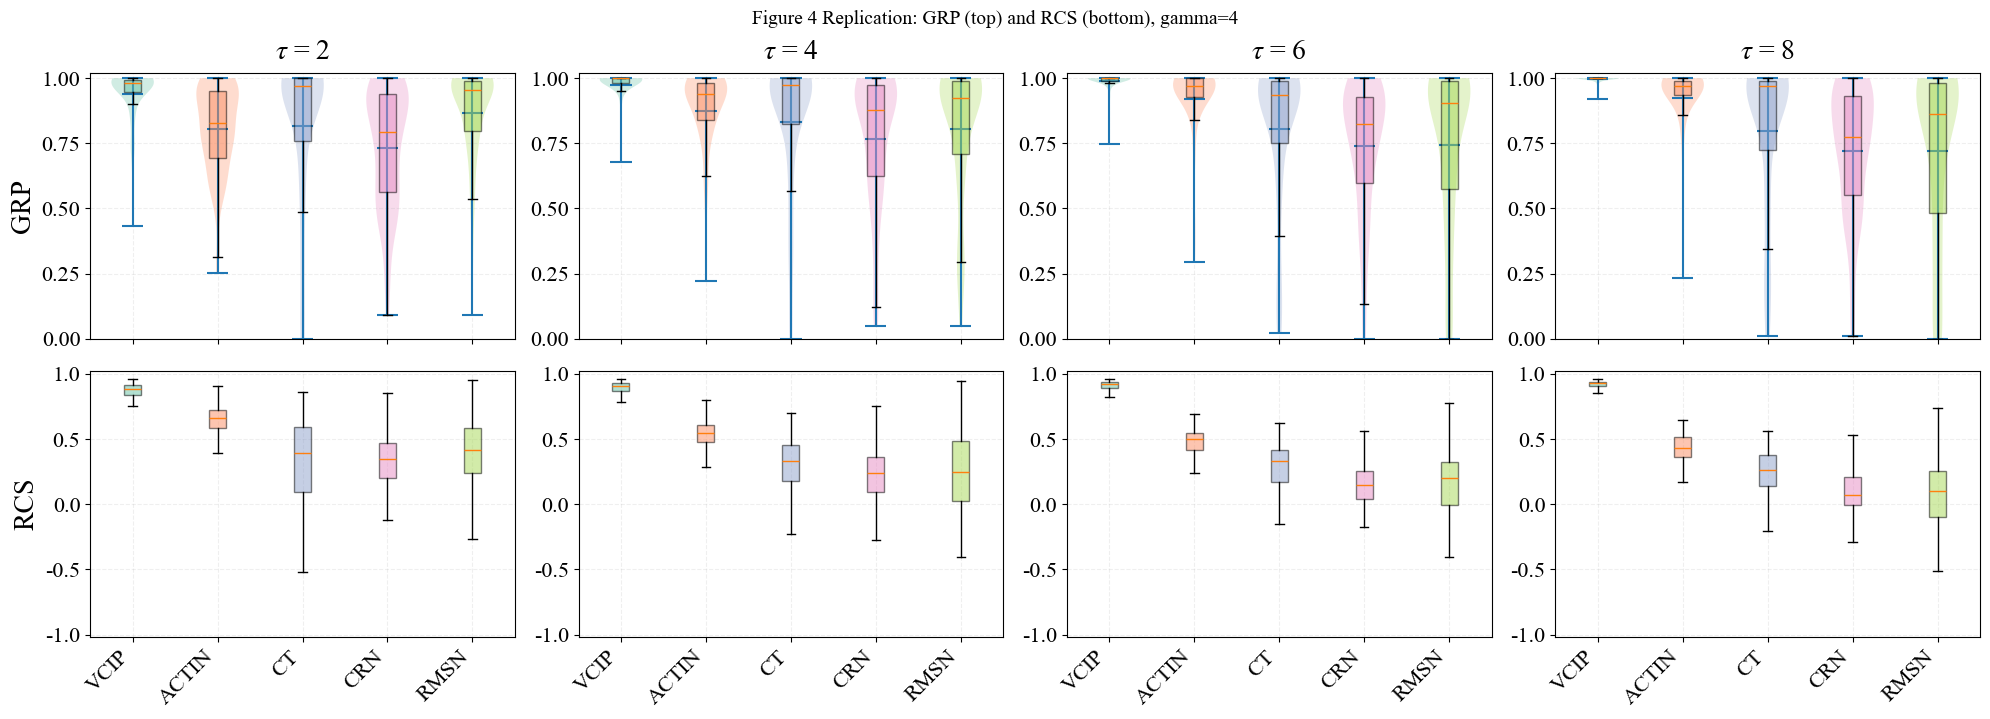

In [3]:
# Use seed=10, rank=True (test_str='False' means exp.test=False, i.e. identical strategies)
merged_data_g4 = case_data['coeff_4']['10']['False']
fig = plot_combined_distributions(merged_data_g4, tau_values=[2, 4, 6, 8], vi=False)
fig.suptitle('Figure 4 Replication: GRP (top) and RCS (bottom), gamma=4', y=1.02, fontsize=14)
plt.show()

## 3. GRP and RCS Summary Tables (gamma=4)

Mean +/- std across 5 seeds for GRP and RCS at tau=2,4,6,8.

In [4]:
def compute_grp_rcs_table(case_data, coeff, test_str='False'):
    """Compute GRP and RCS mean+std across seeds for a given gamma."""
    coeff_key = f'coeff_{coeff}'
    results = {'GRP': {}, 'RCS': {}}
    
    for model in MODELS:
        grp_by_tau = {}
        rcs_by_tau = {}
        for seed in SEEDS:
            if seed not in case_data[coeff_key]:
                continue
            if model not in case_data[coeff_key][seed][test_str]:
                continue
            model_data = case_data[coeff_key][seed][test_str][model]
            for tau in TAU_VALUES:
                if tau not in model_data:
                    continue
                ranks = [c['true_sequence_rank'] for c in model_data[tau]]
                grp = np.mean((100 - np.array(ranks)) / 99)
                corrs = [c['correlations']['model_true'] for c in model_data[tau]]
                corrs = np.array(corrs)
                rcs = np.nanmean(corrs)
                grp_by_tau.setdefault(tau, []).append(grp)
                rcs_by_tau.setdefault(tau, []).append(rcs)
        
        results['GRP'][model] = {tau: (np.mean(v), np.std(v)) for tau, v in grp_by_tau.items()}
        results['RCS'][model] = {tau: (np.mean(v), np.std(v)) for tau, v in rcs_by_tau.items()}
    
    return results

def print_metric_table(results, metric, title):
    print(f'\n{title}')
    print(f'{"Model":<10}', end='')
    for tau in TAU_VALUES:
        print(f'{"tau="+str(tau):>20}', end='')
    print()
    print('-' * 90)
    for model in MODELS:
        print(f'{model:<10}', end='')
        for tau in TAU_VALUES:
            if tau in results[metric][model]:
                m, s = results[metric][model][tau]
                print(f'{m:>14.3f} +/- {s:.3f}', end='')
            else:
                print(f'{"N/A":>20}', end='')
        print()

# gamma=4 results
results_g4 = compute_grp_rcs_table(case_data, 4)
print_metric_table(results_g4, 'GRP', 'GRP Results (gamma=4, identical strategies)')
print_metric_table(results_g4, 'RCS', 'RCS Results (gamma=4, identical strategies)')


GRP Results (gamma=4, identical strategies)
Model                    tau=2               tau=4               tau=6               tau=8
------------------------------------------------------------------------------------------
VCIP               0.932 +/- 0.008         0.973 +/- 0.005         0.991 +/- 0.002         0.994 +/- 0.002
ACTIN              0.684 +/- 0.183         0.676 +/- 0.250         0.675 +/- 0.307         0.676 +/- 0.323
CT                 0.536 +/- 0.198         0.544 +/- 0.205         0.532 +/- 0.181         0.521 +/- 0.207
CRN                0.688 +/- 0.114         0.690 +/- 0.173         0.677 +/- 0.190         0.663 +/- 0.207
RMSN               0.657 +/- 0.233         0.578 +/- 0.260         0.510 +/- 0.244         0.461 +/- 0.240

RCS Results (gamma=4, identical strategies)
Model                    tau=2               tau=4               tau=6               tau=8
------------------------------------------------------------------------------------------
VCIP       

## 4. GRP and RCS across all gamma values

Shows how confounding strength affects model performance.

In [5]:
for gamma in GAMMAS:
    results = compute_grp_rcs_table(case_data, gamma)
    print_metric_table(results, 'GRP', f'GRP Results (gamma={gamma})')
    print()


GRP Results (gamma=1)
Model                    tau=2               tau=4               tau=6               tau=8
------------------------------------------------------------------------------------------
VCIP               0.683 +/- 0.034         0.751 +/- 0.028         0.795 +/- 0.022         0.831 +/- 0.011
ACTIN              0.501 +/- 0.152         0.514 +/- 0.133         0.498 +/- 0.147         0.466 +/- 0.146
CT                 0.536 +/- 0.084         0.522 +/- 0.084         0.527 +/- 0.091         0.526 +/- 0.095
CRN                0.430 +/- 0.096         0.349 +/- 0.089         0.318 +/- 0.109         0.301 +/- 0.103
RMSN               0.533 +/- 0.077         0.519 +/- 0.056         0.467 +/- 0.053         0.459 +/- 0.053


GRP Results (gamma=2)
Model                    tau=2               tau=4               tau=6               tau=8
------------------------------------------------------------------------------------------
VCIP               0.814 +/- 0.017         0.887 +/- 0

## 5. Table 1: Long-range MSE (identical strategies, gamma=4, tau=1..12)

RMSE mean +/- std over 5 seeds.

In [6]:
def print_mse_table(mse_data, coeff, test_str='False', tau_list=range(1, 13)):
    coeff_key = f'coeff_{coeff}'
    if coeff_key not in mse_data:
        print(f'No data for {coeff_key}')
        return
    
    print(f'\nMSE Table (gamma={coeff}, test={test_str})')
    header = f'{"Model":<10}'
    for tau in tau_list:
        header += f'{"tau="+str(tau):>14}'
    print(header)
    print('-' * (10 + 14 * len(list(tau_list))))
    
    all_models = MODELS.copy()
    # Add ablation models if available
    for m in ['VCIP_ablation', 'RMSN_ab']:
        if m in mse_data[coeff_key][test_str]:
            all_models.append(m)
    
    for model in all_models:
        if model not in mse_data[coeff_key][test_str]:
            continue
        df = mse_data[coeff_key][test_str][model]
        row = f'{model:<10}'
        for tau in tau_list:
            col = f'tau={tau}'
            if col in df.columns:
                mean = df[col].mean()
                std = df[col].std()
                row += f'{mean:>8.2f}+/-{std:.2f}'
            else:
                row += f'{"N/A":>14}'
        print(row)

# Table 1: identical strategies (test_str='False' = exp.test=False)
print_mse_table(mse_data, 4, 'False')


MSE Table (gamma=4, test=False)
Model              tau=1         tau=2         tau=3         tau=4         tau=5         tau=6         tau=7         tau=8         tau=9        tau=10        tau=11        tau=12
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VCIP          0.29+/-0.08    0.42+/-0.12    0.53+/-0.15    0.60+/-0.15    0.68+/-0.18    0.75+/-0.19    0.77+/-0.16    0.93+/-0.23    0.95+/-0.24    0.99+/-0.26    1.05+/-0.26    1.10+/-0.29
ACTIN         0.43+/-0.21    0.75+/-0.26    0.99+/-0.33    1.14+/-0.40    1.29+/-0.35    1.37+/-0.31    1.49+/-0.33    1.58+/-0.30    1.66+/-0.29    1.70+/-0.32    1.76+/-0.36    1.79+/-0.37
CT            0.38+/-0.10    0.67+/-0.19    0.88+/-0.23    1.14+/-0.32    1.29+/-0.33    1.43+/-0.39    1.58+/-0.39    1.62+/-0.42    1.76+/-0.38    1.84+/-0.43    1.95+/-0.49    1.97+/-0.46
CRN           0.39+/-0.10    0.62+/-

## 6. Table 3: Ablation Study (gamma=4)

Compares VCIP vs VCIP_ablation and RMSN vs RMSN_ab.

In [7]:
# Ablation GRP/RCS
def compute_ablation_grp_rcs(case_data, coeff=4, test_str='False'):
    coeff_key = f'coeff_{coeff}'
    ablation_models = ['VCIP', 'VCIP_ablation', 'RMSN', 'RMSN_ab']
    results = {}
    
    for model in ablation_models:
        grp_by_tau = {}
        rcs_by_tau = {}
        for seed in SEEDS:
            if seed not in case_data.get(coeff_key, {}):
                continue
            if model not in case_data[coeff_key][seed].get(test_str, {}):
                continue
            model_data = case_data[coeff_key][seed][test_str][model]
            for tau in [2, 4]:
                if tau not in model_data:
                    continue
                ranks = [c['true_sequence_rank'] for c in model_data[tau]]
                grp = np.mean((100 - np.array(ranks)) / 99)
                corrs = [c['correlations']['model_true'] for c in model_data[tau]]
                rcs = np.nanmean(corrs)
                grp_by_tau.setdefault(tau, []).append(grp)
                rcs_by_tau.setdefault(tau, []).append(rcs)
        
        if grp_by_tau:
            results[model] = {
                'GRP': {tau: (np.mean(v), np.std(v)) for tau, v in grp_by_tau.items()},
                'RCS': {tau: (np.mean(v), np.std(v)) for tau, v in rcs_by_tau.items()}
            }
    
    print('\nAblation Study (gamma=4)')
    print(f'{"Model":<18} {"GRP tau=2":>16} {"GRP tau=4":>16} {"RCS tau=2":>16} {"RCS tau=4":>16}')
    print('-' * 82)
    for model in ablation_models:
        if model not in results:
            print(f'{model:<18} {"N/A":>16} {"N/A":>16} {"N/A":>16} {"N/A":>16}')
            continue
        r = results[model]
        vals = []
        for metric in ['GRP', 'RCS']:
            for tau in [2, 4]:
                if tau in r[metric]:
                    m, s = r[metric][tau]
                    vals.append(f'{m:.3f}+/-{s:.3f}')
                else:
                    vals.append('N/A')
        print(f'{model:<18} {vals[0]:>16} {vals[1]:>16} {vals[2]:>16} {vals[3]:>16}')

compute_ablation_grp_rcs(case_data)


Ablation Study (gamma=4)
Model                     GRP tau=2        GRP tau=4        RCS tau=2        RCS tau=4
----------------------------------------------------------------------------------
VCIP                  0.932+/-0.008    0.973+/-0.005    0.751+/-0.038    0.843+/-0.020
VCIP_ablation         0.738+/-0.026    0.764+/-0.016    0.443+/-0.067    0.482+/-0.048
RMSN                  0.657+/-0.233    0.578+/-0.260    0.285+/-0.266    0.113+/-0.280
RMSN_ab               0.694+/-0.154    0.579+/-0.264    0.393+/-0.132    0.166+/-0.260


## 7. Figure 6: Target Distances (gamma=1,2,3, tau=1..6)

MSE trends across models for different confounding levels.

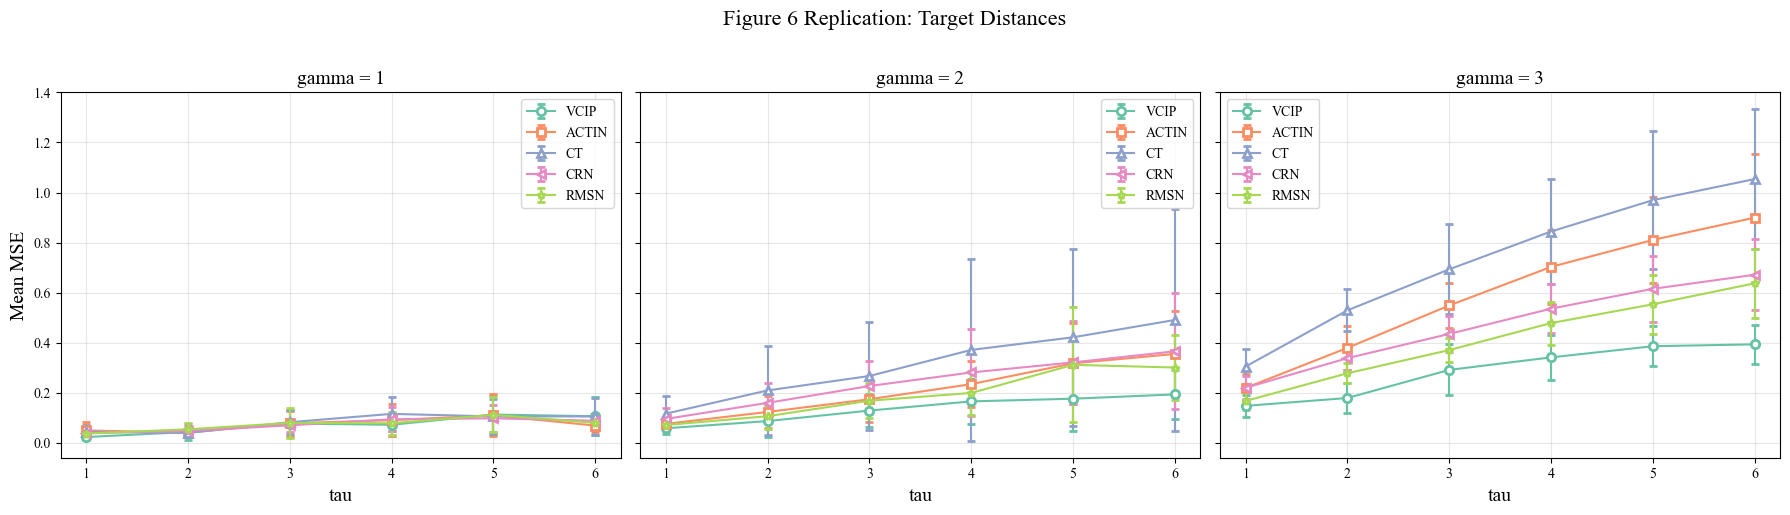

In [8]:
# Plot MSE trends for gamma=1,2,3
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = sns.color_palette('Set2', len(MODELS))
markers = ['o', 's', '^', '<', '*']

for idx, gamma in enumerate([1, 2, 3]):
    ax = axes[idx]
    coeff_key = f'coeff_{gamma}'
    
    for m_idx, model in enumerate(MODELS):
        if model not in mse_data.get(coeff_key, {}).get('False', {}):
            continue
        df = mse_data[coeff_key]['False'][model]
        taus = range(1, 7)
        means = [df[f'tau={t}'].mean() for t in taus]
        stds = [df[f'tau={t}'].std() for t in taus]
        ax.errorbar(list(taus), means, yerr=stds, label=model,
                    color=colors[m_idx], marker=markers[m_idx],
                    linewidth=1.5, markersize=6, markerfacecolor='white',
                    markeredgewidth=2, capsize=3)
    
    ax.set_xlabel('tau', fontsize=14)
    if idx == 0:
        ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title(f'gamma = {gamma}', fontsize=14)
    ax.set_xticks(range(1, 7))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

fig.suptitle('Figure 6 Replication: Target Distances', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. MSE Tables for all gamma values

In [9]:
for gamma in GAMMAS:
    print_mse_table(mse_data, gamma, 'False', range(1, 7))
    print()


MSE Table (gamma=1, test=False)
Model              tau=1         tau=2         tau=3         tau=4         tau=5         tau=6
----------------------------------------------------------------------------------------------
VCIP          0.02+/-0.01    0.04+/-0.03    0.08+/-0.05    0.07+/-0.05    0.11+/-0.08    0.11+/-0.08
ACTIN         0.05+/-0.03    0.04+/-0.02    0.08+/-0.05    0.09+/-0.06    0.11+/-0.08    0.07+/-0.03
CT            0.04+/-0.03    0.04+/-0.02    0.08+/-0.05    0.12+/-0.07    0.11+/-0.07    0.11+/-0.07
CRN           0.04+/-0.02    0.05+/-0.02    0.07+/-0.03    0.09+/-0.05    0.10+/-0.05    0.09+/-0.02
RMSN          0.04+/-0.02    0.05+/-0.02    0.08+/-0.06    0.08+/-0.05    0.11+/-0.07    0.08+/-0.02


MSE Table (gamma=2, test=False)
Model              tau=1         tau=2         tau=3         tau=4         tau=5         tau=6
----------------------------------------------------------------------------------------------
VCIP          0.06+/-0.02    0.09+/-0.06    0.13

## 9. Confounding Sensitivity Analysis

How does each model's GRP degrade as confounding strength (gamma) increases?

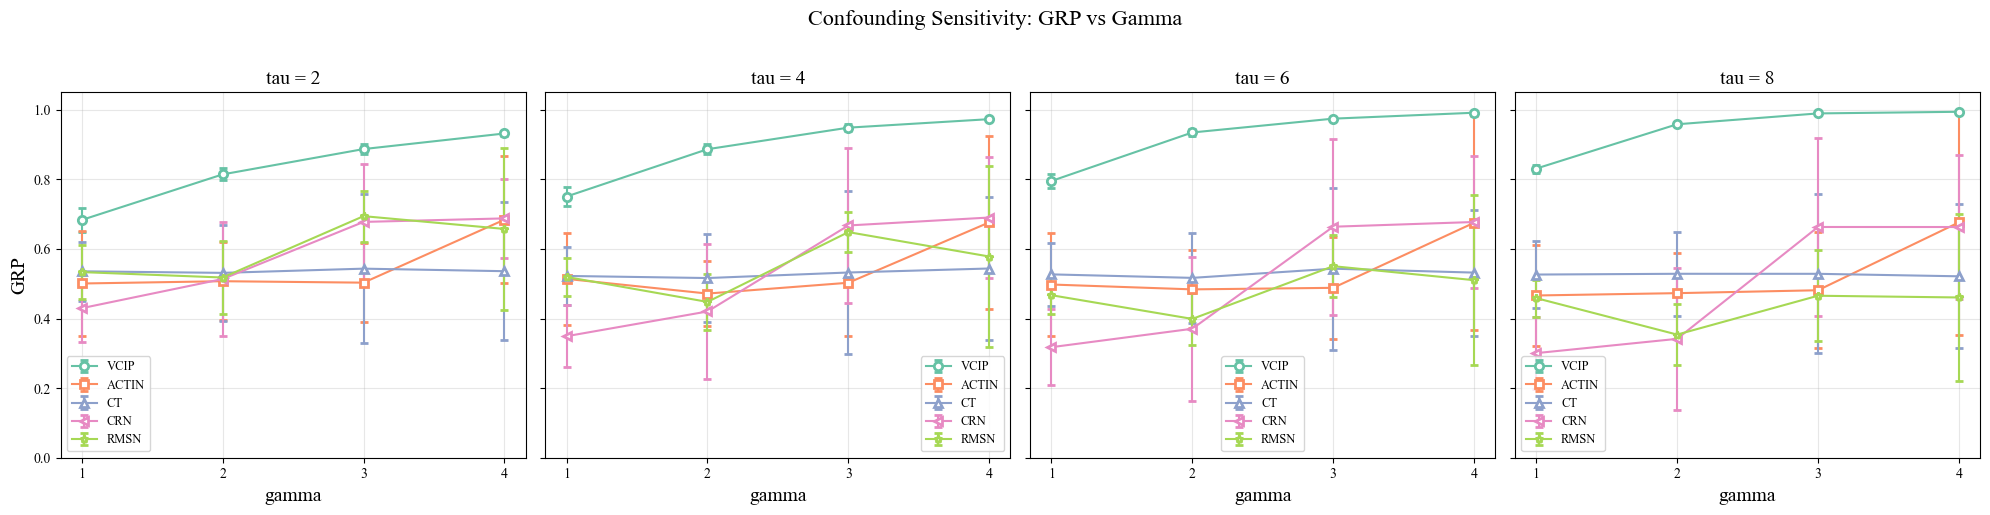

In [10]:
# GRP vs gamma for each model at fixed tau values
fig, axes = plt.subplots(1, len(TAU_VALUES), figsize=(20, 5), sharey=True)
colors = sns.color_palette('Set2', len(MODELS))
markers = ['o', 's', '^', '<', '*']

for t_idx, tau in enumerate(TAU_VALUES):
    ax = axes[t_idx]
    for m_idx, model in enumerate(MODELS):
        grp_means = []
        grp_stds = []
        gammas_available = []
        for gamma in GAMMAS:
            coeff_key = f'coeff_{gamma}'
            grps = []
            for seed in SEEDS:
                if seed not in case_data.get(coeff_key, {}):
                    continue
                if model not in case_data[coeff_key][seed].get('False', {}):
                    continue
                model_data = case_data[coeff_key][seed]['False'][model]
                if tau not in model_data:
                    continue
                ranks = [c['true_sequence_rank'] for c in model_data[tau]]
                grps.append(np.mean((100 - np.array(ranks)) / 99))
            if grps:
                grp_means.append(np.mean(grps))
                grp_stds.append(np.std(grps))
                gammas_available.append(gamma)
        
        if gammas_available:
            ax.errorbar(gammas_available, grp_means, yerr=grp_stds, label=model,
                        color=colors[m_idx], marker=markers[m_idx],
                        linewidth=1.5, markersize=6, markerfacecolor='white',
                        markeredgewidth=2, capsize=3)
    
    ax.set_xlabel('gamma', fontsize=14)
    if t_idx == 0:
        ax.set_ylabel('GRP', fontsize=14)
    ax.set_title(f'tau = {tau}', fontsize=14)
    ax.set_xticks(GAMMAS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

fig.suptitle('Confounding Sensitivity: GRP vs Gamma', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Quantitative confounding sensitivity table
print('Confounding Sensitivity: GRP degradation from gamma=1 to gamma=4')
print(f'{"Model":<10} {"tau=2":>12} {"tau=4":>12} {"tau=6":>12} {"tau=8":>12}')
print('-' * 58)

for model in MODELS:
    row = f'{model:<10}'
    for tau in TAU_VALUES:
        grp_g1 = []
        grp_g4 = []
        for seed in SEEDS:
            for gamma, grp_list in [(1, grp_g1), (4, grp_g4)]:
                coeff_key = f'coeff_{gamma}'
                if seed in case_data.get(coeff_key, {}) and model in case_data[coeff_key][seed].get('False', {}):
                    model_data = case_data[coeff_key][seed]['False'][model]
                    if tau in model_data:
                        ranks = [c['true_sequence_rank'] for c in model_data[tau]]
                        grp_list.append(np.mean((100 - np.array(ranks)) / 99))
        if grp_g1 and grp_g4:
            delta = np.mean(grp_g1) - np.mean(grp_g4)
            row += f'{delta:>+12.3f}'
        else:
            row += f'{"N/A":>12}'
    print(row)

Confounding Sensitivity: GRP degradation from gamma=1 to gamma=4
Model             tau=2        tau=4        tau=6        tau=8
----------------------------------------------------------
VCIP            -0.248      -0.222      -0.196      -0.163
ACTIN           -0.183      -0.162      -0.177      -0.210
CT              -0.000      -0.021      -0.005      +0.005
CRN             -0.258      -0.341      -0.360      -0.362
RMSN            -0.124      -0.059      -0.043      -0.002


## 10. Per-seed GRP Distributions (gamma=4)

Violin+box plots aggregating all seeds.

['VCIP', 'ACTIN', 'CT', 'CRN', 'RMSN']
tau = 2, rank, VCIP: 0.932 $\pm$ 0.112
tau = 2, rank, RMSN: 0.657 $\pm$ 0.376
tau = 4, rank, VCIP: 0.973 $\pm$ 0.059
tau = 4, rank, RMSN: 0.578 $\pm$ 0.435
tau = 2, corrs, VCIP: 0.751 $\pm$ 0.226
tau = 2, corrs, RMSN: 0.287 $\pm$ 0.579
tau = 4, corrs, VCIP: 0.842 $\pm$ 0.182
tau = 4, corrs, RMSN: 0.115 $\pm$ 0.604


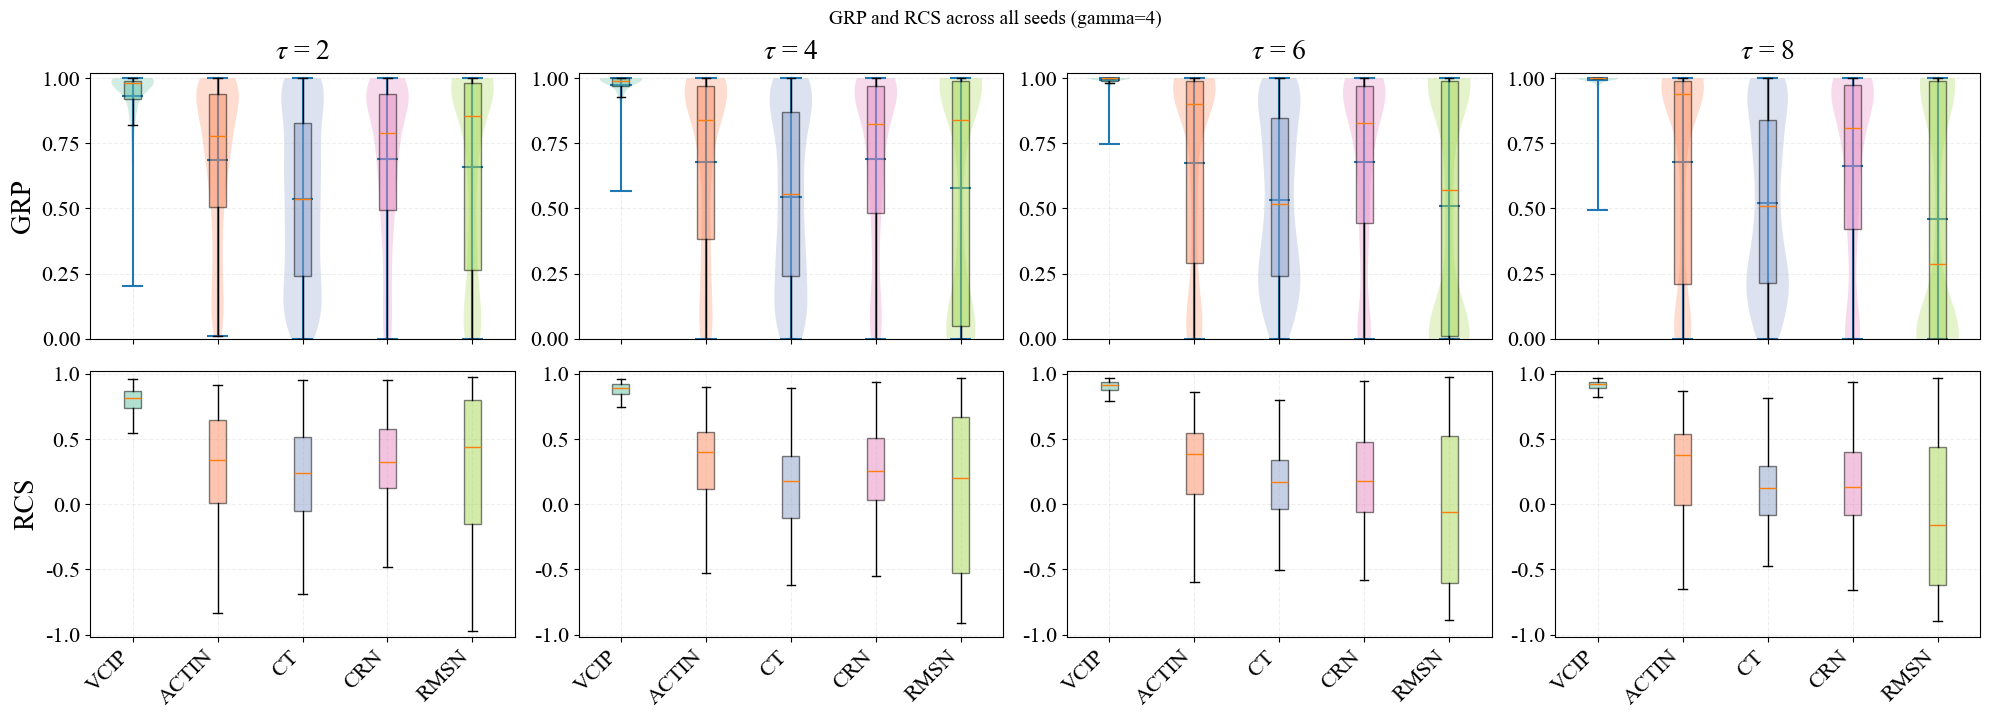

In [12]:
# Merge all seeds for gamma=4
merged_all_seeds = {}
for model in MODELS:
    merged_all_seeds[model] = {}
    for tau in TAU_VALUES:
        all_cases = []
        for seed in SEEDS:
            if seed in case_data.get('coeff_4', {}) and model in case_data['coeff_4'][seed].get('False', {}):
                if tau in case_data['coeff_4'][seed]['False'][model]:
                    all_cases.extend(case_data['coeff_4'][seed]['False'][model][tau])
        if all_cases:
            merged_all_seeds[model][tau] = all_cases

fig = plot_combined_distributions(merged_all_seeds, tau_values=[2, 4, 6, 8], vi=False)
fig.suptitle('GRP and RCS across all seeds (gamma=4)', y=1.02, fontsize=14)
plt.show()

## 11. Summary and Paper Comparison

In [13]:
print('=' * 80)
print('REPLICATION SUMMARY')
print('=' * 80)
print()

# Paper claims to verify
print('Paper Claims Verification (Cancer Simulation):')
print()

# Claim 1: VCIP outperforms all baselines
results_g4 = compute_grp_rcs_table(case_data, 4)
vcip_grp = {tau: results_g4['GRP']['VCIP'][tau][0] for tau in TAU_VALUES}
claim1 = True
for model in ['ACTIN', 'CT', 'CRN', 'RMSN']:
    for tau in TAU_VALUES:
        if tau in results_g4['GRP'][model]:
            if results_g4['GRP'][model][tau][0] >= vcip_grp[tau]:
                claim1 = False
                print(f'  FAILED: {model} GRP >= VCIP at tau={tau}')

status = 'VERIFIED' if claim1 else 'FAILED'
print(f'  (1) VCIP outperforms all baselines at every tau: {status}')

# Claim 2: Baselines degrade with larger tau
claim2 = True
for model in ['ACTIN', 'CT', 'CRN', 'RMSN']:
    if 2 in results_g4['GRP'][model] and 8 in results_g4['GRP'][model]:
        if results_g4['GRP'][model][8][0] > results_g4['GRP'][model][2][0]:
            claim2 = False
            print(f'  FAILED: {model} GRP improves from tau=2 to tau=8')

status = 'VERIFIED' if claim2 else 'PARTIAL'
print(f'  (2) Baselines degrade with larger tau: {status}')

# Claim 3: VCIP improves with larger tau
claim3 = vcip_grp.get(8, 0) > vcip_grp.get(2, 1)
status = 'VERIFIED' if claim3 else 'FAILED'
print(f'  (3) VCIP improves with larger tau: {status}')
print(f'      GRP: {vcip_grp.get(2, "N/A"):.3f} (tau=2) -> {vcip_grp.get(8, "N/A"):.3f} (tau=8)')

print()
print('Full GRP table (gamma=4):')
print_metric_table(results_g4, 'GRP', '')

REPLICATION SUMMARY

Paper Claims Verification (Cancer Simulation):

  (1) VCIP outperforms all baselines at every tau: VERIFIED
  (2) Baselines degrade with larger tau: VERIFIED
  (3) VCIP improves with larger tau: VERIFIED
      GRP: 0.932 (tau=2) -> 0.994 (tau=8)

Full GRP table (gamma=4):


Model                    tau=2               tau=4               tau=6               tau=8
------------------------------------------------------------------------------------------
VCIP               0.932 +/- 0.008         0.973 +/- 0.005         0.991 +/- 0.002         0.994 +/- 0.002
ACTIN              0.684 +/- 0.183         0.676 +/- 0.250         0.675 +/- 0.307         0.676 +/- 0.323
CT                 0.536 +/- 0.198         0.544 +/- 0.205         0.532 +/- 0.181         0.521 +/- 0.207
CRN                0.688 +/- 0.114         0.690 +/- 0.173         0.677 +/- 0.190         0.663 +/- 0.207
RMSN               0.657 +/- 0.233         0.578 +/- 0.260         0.510 +/- 0.244         0.4